# ch246 — Bayes' Theorem

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. The Problem

You have a prior belief. You observe evidence. How should you update your belief?

Bayes' theorem answers this precisely. It is not a heuristic or a metaphor — it is an algebraic consequence of the definition of conditional probability *(introduced in ch245)*.

---

## 2. Derivation from First Principles

From the multiplication rule (ch245):
$$P(A \cap B) = P(A \mid B) \cdot P(B)$$
$$P(A \cap B) = P(B \mid A) \cdot P(A)$$

Both expressions equal P(A ∩ B). Set them equal:
$$P(A \mid B) \cdot P(B) = P(B \mid A) \cdot P(A)$$

Solve for P(A|B):
$$\boxed{P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}}$$

In the context of belief updating:
- **A** = hypothesis (e.g., "email is spam")
- **B** = observed evidence (e.g., "email contains 'offer'")
- **P(A)** = prior — your belief before seeing evidence
- **P(B|A)** = likelihood — probability of evidence given the hypothesis
- **P(B)** = marginal likelihood — probability of evidence under any hypothesis
- **P(A|B)** = posterior — updated belief after evidence

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def bayes_update(prior: float, likelihood: float, p_evidence: float) -> float:
    """
    Compute posterior P(H|E) given:
      prior      = P(H)
      likelihood = P(E|H)
      p_evidence = P(E) — marginal probability of evidence
    """
    return (likelihood * prior) / p_evidence


# Spam filter from the Part VIII intro
p_spam = 0.30              # P(spam)
p_legit = 1 - p_spam       # P(legit)
p_offer_given_spam = 0.40  # P('offer' | spam)
p_offer_given_legit = 0.05 # P('offer' | legit)

# Law of total probability: P('offer') = P('offer'|spam)P(spam) + P('offer'|legit)P(legit)
p_offer = p_offer_given_spam * p_spam + p_offer_given_legit * p_legit

# Bayes' theorem
p_spam_given_offer = bayes_update(p_spam, p_offer_given_spam, p_offer)

print("Spam Filter — Bayes' Theorem")
print(f"  Prior P(spam) = {p_spam:.4f}")
print(f"  P('offer' | spam) = {p_offer_given_spam:.4f}")
print(f"  P('offer' | legit) = {p_offer_given_legit:.4f}")
print(f"  P('offer') = {p_offer:.4f}  [law of total probability]")
print(f"  Posterior P(spam | 'offer') = {p_spam_given_offer:.4f}")

Spam Filter — Bayes' Theorem
  Prior P(spam) = 0.3000
  P('offer' | spam) = 0.4000
  P('offer' | legit) = 0.0500
  P('offer') = 0.1550  [law of total probability]
  Posterior P(spam | 'offer') = 0.7742


The prior was 30% spam. Observing "offer" shifts the posterior to 77.4%. The word carries strong evidence because it is 8× more common in spam than in legitimate mail.

---

## 3. The Full Form With a Partition

When H and Hᶜ partition Ω, the denominator P(B) can always be expanded using the law of total probability:
$$P(H \mid E) = \frac{P(E \mid H) \cdot P(H)}{P(E \mid H) \cdot P(H) + P(E \mid H^c) \cdot P(H^c)}$$

This form is self-contained — you never need to know P(E) directly.

In [2]:
def bayes_two_class(prior_h: float, likelihood_h: float, likelihood_not_h: float) -> float:
    """
    P(H|E) using full Bayes with expanded denominator.
    No need to pre-compute P(E).
    """
    numerator = likelihood_h * prior_h
    denominator = likelihood_h * prior_h + likelihood_not_h * (1 - prior_h)
    return numerator / denominator


# Medical test example
# Disease prevalence: 1%
# Test sensitivity (true positive rate): 99%
# Test specificity (true negative rate): 95% → false positive rate: 5%

prior_disease = 0.01
sensitivity = 0.99   # P(positive | disease)
false_positive = 0.05  # P(positive | no disease)

posterior = bayes_two_class(prior_disease, sensitivity, false_positive)

print("Medical Test Example")
print(f"  Disease prevalence: {prior_disease:.0%}")
print(f"  Test sensitivity: {sensitivity:.0%}")
print(f"  False positive rate: {false_positive:.0%}")
print(f"  P(disease | positive test) = {posterior:.4f} ({posterior:.1%})")
print()
print("  Despite 99% sensitivity, a positive test on a low-prevalence")
print(f"  disease means only {posterior:.1%} chance of actually having it.")
print("  This is the base rate fallacy — Bayes corrects for it.")

Medical Test Example
  Disease prevalence: 1%
  Test sensitivity: 99%
  False positive rate: 5%
  P(disease | positive test) = 0.1667 (16.7%)

  Despite 99% sensitivity, a positive test on a low-prevalence
  disease means only 16.7% chance of actually having it.
  This is the base rate fallacy — Bayes corrects for it.


## 4. Bayesian Updating Sequentially

Each posterior becomes the next prior. Evidence accumulates.

Sequential updates after each spam word:
  Prior             : 0.3000  ████████████
  After 'offer'     : 0.7742  ██████████████████████████████
  After 'free'      : 0.9536  ██████████████████████████████████████
  After 'win'       : 0.9923  ███████████████████████████████████████


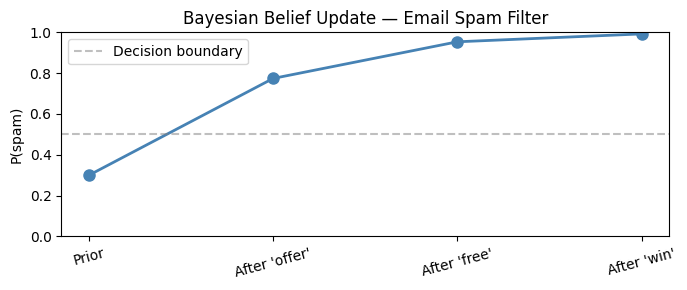

In [3]:
# Sequential Bayesian updating
# Each email is independently scanned for spam words.
# Words: 'offer', 'free', 'win'

likelihoods_spam  = {'offer': 0.40, 'free': 0.60, 'win': 0.50}
likelihoods_legit = {'offer': 0.05, 'free': 0.10, 'win': 0.08}

def sequential_bayes(prior, words_found):
    posterior = prior
    history = [prior]
    for word in words_found:
        posterior = bayes_two_class(
            posterior,
            likelihoods_spam[word],
            likelihoods_legit[word]
        )
        history.append(posterior)
    return posterior, history

words = ['offer', 'free', 'win']
final_p, history = sequential_bayes(prior=0.30, words_found=words)

print("Sequential updates after each spam word:")
labels = ['Prior'] + [f"After '{w}'" for w in words]
for label, p in zip(labels, history):
    bar = '█' * int(p * 40)
    print(f"  {label:<18}: {p:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(len(history)), history, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
ax.set_xticks(range(len(history)))
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('P(spam)')
ax.set_title('Bayesian Belief Update — Email Spam Filter')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Bayes' Theorem in Machine Learning

Every probabilistic ML model applies Bayes' theorem:

$$P(\text{class} \mid \text{features}) = \frac{P(\text{features} \mid \text{class}) \cdot P(\text{class})}{P(\text{features})}$$

- **Naive Bayes classifier**: assumes features are independent given class, factoring the likelihood.
- **Bayesian neural networks**: place priors on weights, compute posterior distributions.
- **Kalman filter**: sequential Bayesian updates for state estimation.
- **A/B testing**: update beliefs about conversion rates as data accumulates *(see ch286).*

In [4]:
# Minimal Naive Bayes classifier from scratch
# Training data: (word_count_offer, label)

class NaiveBayesBinaryClassifier:
    """Naive Bayes for binary classification from counts."""
    
    def __init__(self):
        self.prior = {}
        self.likelihoods = {}  # {class: {feature: P(feature|class)}}
    
    def fit(self, X, y, feature_names):
        """
        X: shape (n_samples, n_features) — binary feature presence
        y: labels (0 or 1)
        """
        X, y = np.array(X), np.array(y)
        classes = np.unique(y)
        n = len(y)
        
        for c in classes:
            mask = y == c
            self.prior[c] = mask.sum() / n
            # Laplace smoothing: add 1 to numerator and denominator
            self.likelihoods[c] = {
                feat: (X[mask, i].sum() + 1) / (mask.sum() + 2)
                for i, feat in enumerate(feature_names)
            }
        self.feature_names = feature_names
        return self
    
    def predict_proba(self, x, feature_names):
        """Return P(class=1 | x) using Bayes' theorem."""
        scores = {}
        for c, prior in self.prior.items():
            log_prob = np.log(prior)
            for i, feat in enumerate(feature_names):
                p = self.likelihoods[c][feat]
                log_prob += np.log(p) if x[i] == 1 else np.log(1 - p)
            scores[c] = log_prob
        # Convert log-probabilities to normalized probabilities
        max_log = max(scores.values())
        exp_scores = {c: np.exp(v - max_log) for c, v in scores.items()}
        total = sum(exp_scores.values())
        return {c: v / total for c, v in exp_scores.items()}


# Tiny dataset: [has_offer, has_free, has_win] → spam(1) or legit(0)
features = ['offer', 'free', 'win']
X_train = [
    [1, 1, 0],  # spam
    [1, 0, 1],  # spam
    [0, 1, 1],  # spam
    [0, 0, 0],  # legit
    [1, 0, 0],  # legit
    [0, 0, 0],  # legit
]
y_train = [1, 1, 1, 0, 0, 0]

clf = NaiveBayesBinaryClassifier().fit(X_train, y_train, features)

# Predict a new email: contains 'offer' and 'free'
x_new = [1, 1, 0]
proba = clf.predict_proba(x_new, features)
print(f"New email [offer=1, free=1, win=0]:")
print(f"  P(spam | features) = {proba[1]:.4f}")
print(f"  P(legit | features) = {proba[0]:.4f}")

New email [offer=1, free=1, win=0]:
  P(spam | features) = 0.6923
  P(legit | features) = 0.3077


## 6. Summary

- Bayes' theorem follows directly from the definition of conditional probability — it is not a separate axiom.
- P(H|E) = P(E|H)·P(H) / P(E): posterior = likelihood × prior / evidence.
- The denominator P(E) normalizes the result and can be expanded using the law of total probability.
- Sequential updating: each posterior becomes the prior for the next observation.
- Every probabilistic classifier is an implementation of Bayes' theorem.

---

## 7. Forward References

Bayes' theorem is the backbone of Part IX. It reappears in ch287 (Bayesian Statistics) as a framework for full probabilistic inference, and the prior/posterior distinction drives Bayesian model selection. The likelihood function P(E|H) is formalized through the distributions in ch248–ch253.